### Overwiew

[Dataset](https://www.kaggle.com/datasets/yasserh/wine-quality-dataset)

Columns:
- fixed acidity in g/L
- volatile acidity in g/L
- citric acid in g/L
- residual sugar in g/L
- chlorides in g/L
- free sulfur dioxide in g/L
- total sulfur dioxide in g/L
- density g/cm^3
- pH in number from 0 to 14
- sulphates in g/L
- alcohol in %
- quality in number from 1 to 10

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')





In [3]:
import sys
from google.colab import files

if 'google.colab' in sys.modules:
    uploaded = files.upload()
dataset = pd.read_csv('./WineQT.csv')

Saving WineQT.csv to WineQT.csv


In [4]:
columns_to_exclude = ['quality']
columns_to_clip = [col for col in dataset.columns if col not in columns_to_exclude]

for col in columns_to_clip:
    lower = dataset[col].quantile(0.05)
    upper = dataset[col].quantile(0.95)
    dataset[col] = dataset[col].clip(lower=lower, upper=upper)

dataset.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,84.1
1,7.8,0.84,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,84.1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,84.1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,84.1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,84.1


In [5]:
print("Count:\n", dataset.count())
print("\nStatistics:\n", dataset.describe())
print("\nGaps:\n", dataset.isnull().sum())

Count:
 fixed acidity           1143
volatile acidity        1143
citric acid             1143
residual sugar          1143
chlorides               1143
free sulfur dioxide     1143
total sulfur dioxide    1143
density                 1143
pH                      1143
sulphates               1143
alcohol                 1143
quality                 1143
Id                      1143
dtype: int64

Statistics:
        fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.287927          0.527352     0.265146        2.440822   
std         1.568387          0.159771     0.189828        0.881812   
min         6.100000          0.271000     0.000000        1.600000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        11.900000

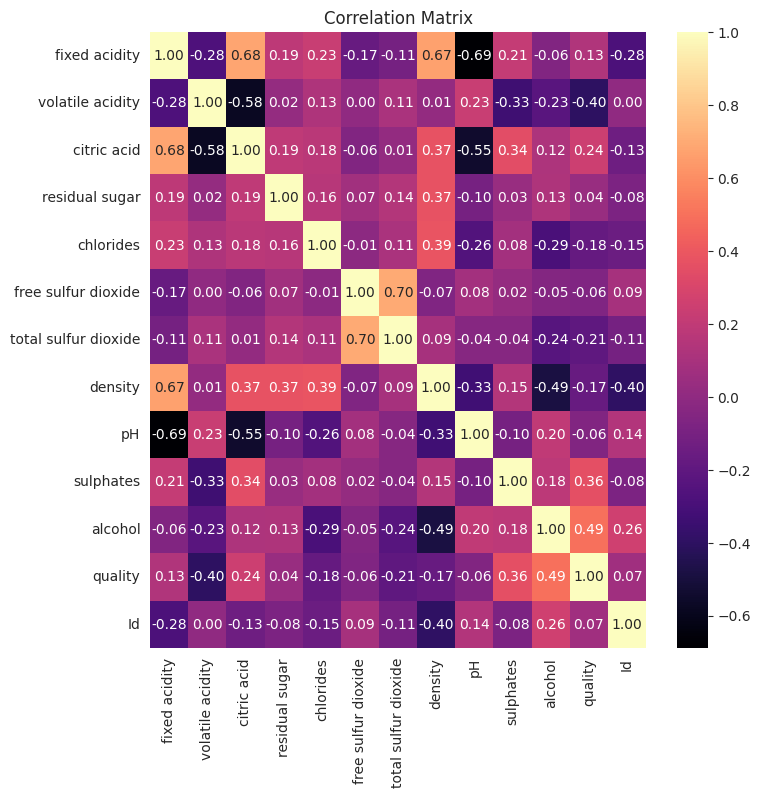

In [6]:
corr = dataset.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(corr, cmap='magma', annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

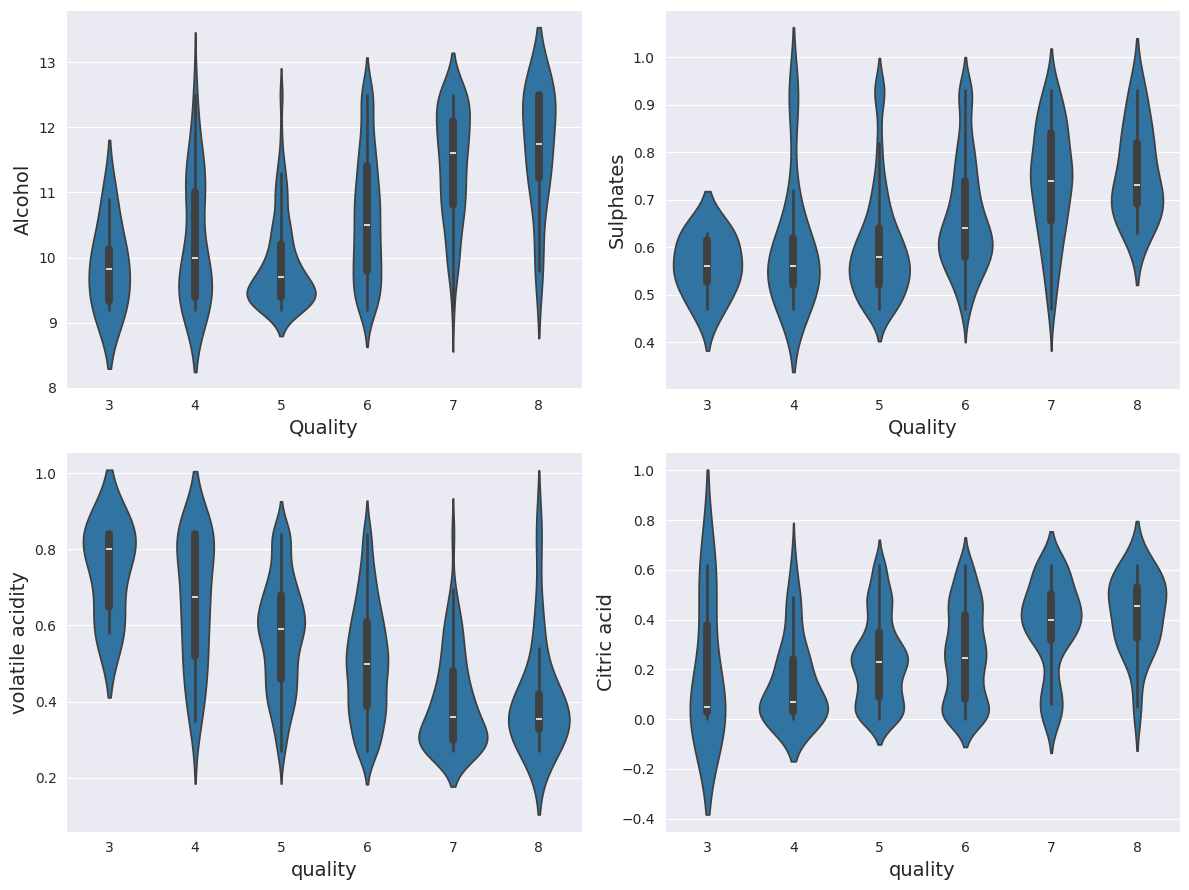

In [7]:
f, axes = plt.subplots(2, 2, figsize=(12,9))

sns.violinplot(x='quality', y='alcohol', data=dataset, ax=axes[0, 0])
axes[0, 0].set_xlabel('Quality', fontsize=14)
axes[0, 0].set_ylabel('Alcohol', fontsize=14)

sns.violinplot(x='quality', y='sulphates', data=dataset, ax=axes[0, 1])
axes[0, 1].set_xlabel('Quality', fontsize=14)
axes[0, 1].set_ylabel('Sulphates', fontsize=14)

sns.violinplot(x='quality', y='volatile acidity', data=dataset, ax=axes[1, 0])
axes[1, 0].set_xlabel('quality', fontsize=14)
axes[1, 0].set_ylabel('volatile acidity', fontsize=14)

sns.violinplot(x='quality', y='citric acid', data=dataset, ax=axes[1, 1])
axes[1, 1].set_xlabel('quality', fontsize=14)
axes[1, 1].set_ylabel('Citric acid', fontsize=14)

plt.tight_layout()
plt.show()

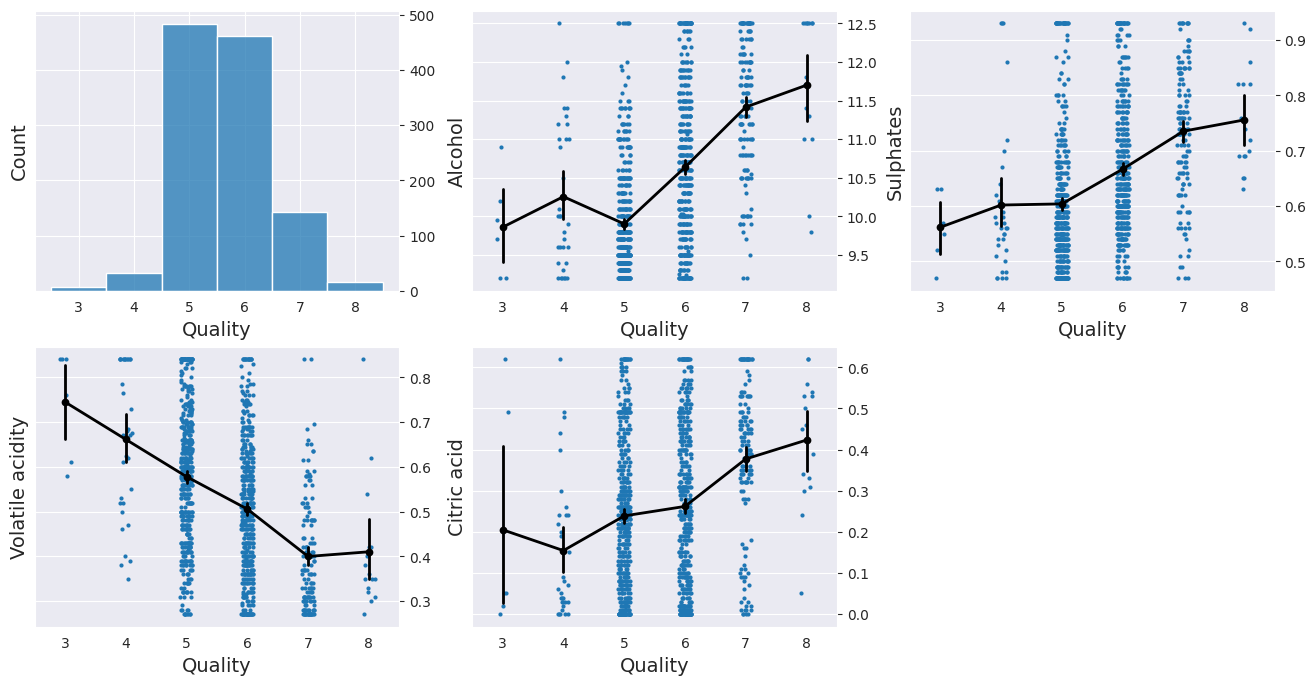

In [8]:
f, axes = plt.subplots(2,3,figsize=(16,8))

sns.histplot(dataset['quality'], ax = axes[0, 0], discrete=True)
axes[0, 0].set_xlabel('Quality', fontsize=14)
axes[0, 0].set_ylabel('Count', fontsize=14)
axes[0, 0].yaxis.tick_right()

sns.pointplot(data=dataset, x="quality", y="alcohol", color='black', ax = axes[0, 1], zorder=10, scale=0.75)
sns.stripplot(x = 'quality', y = 'alcohol', data = dataset, ax = axes[0, 1], size=3)
axes[0, 1].set_xlabel('Quality', fontsize=14)
axes[0, 1].set_ylabel('Alcohol', fontsize=14)
axes[0, 1].yaxis.tick_right()

sns.pointplot(data=dataset, x="quality", y="sulphates", color='black', ax = axes[0, 2], zorder=10, scale=0.75)
sns.stripplot(x = 'quality', y = 'sulphates', data = dataset, ax = axes[0, 2], size=3)
axes[0, 2].set_xlabel('Quality', fontsize=14)
axes[0, 2].set_ylabel('Sulphates', fontsize=14)
axes[0, 2].yaxis.tick_right()

sns.pointplot(data=dataset, x="quality", y="volatile acidity", color='black', ax = axes[1, 0], zorder=10, scale=0.75)
sns.stripplot(x = 'quality', y = 'volatile acidity', data = dataset, ax = axes[1, 0], size=3)
axes[1, 0].set_xlabel('Quality', fontsize=14)
axes[1, 0].set_ylabel('Volatile acidity', fontsize=14)
axes[1, 0].yaxis.tick_right()

sns.pointplot(data=dataset, x="quality", y="citric acid", color='black', ax = axes[1, 1], zorder=10, scale=0.75)
sns.stripplot(x = 'quality', y = 'citric acid', data = dataset, ax = axes[1, 1], size=3)
axes[1, 1].set_xlabel('Quality', fontsize=14)
axes[1, 1].set_ylabel('Citric acid', fontsize=14)
axes[1, 1].yaxis.tick_right()

axes[1, 2].set_visible(False)
plt.show()

In [23]:
X = dataset.drop('quality', axis=1).values
y = dataset['quality'].values.reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Shape of X_train: ", X_train.shape)
print("Shape of X_test: ", X_test.shape)

Shape of X_train:  (857, 12)
Shape of X_test:  (286, 12)


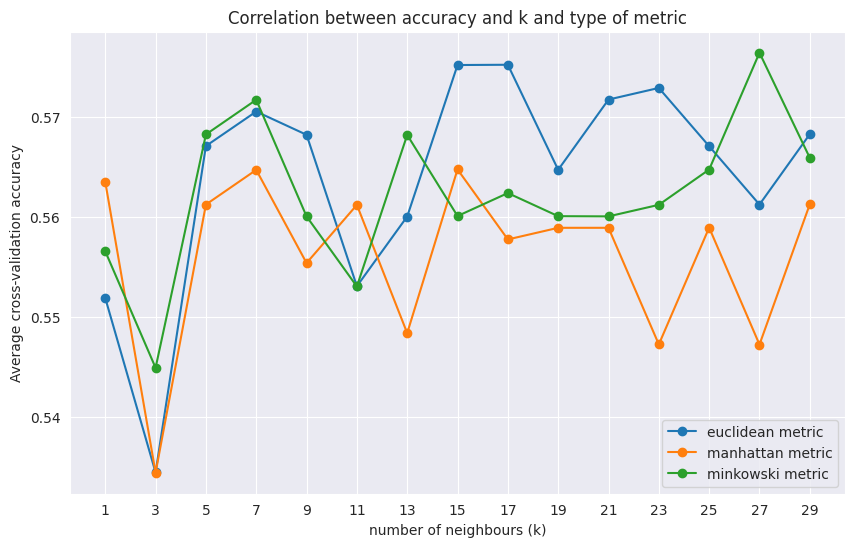

In [36]:
k_range = range(1, 31, 2)
metrics = ['euclidean', 'manhattan', 'minkowski']
cv_scores = {}

X_train_s = scaler.fit_transform(X_train)

for metric in metrics:
    cv_scores[metric] = []
    sklearn_p = 2 if metric == 'euclidean' else (3 if metric == 'minkowski' else 1)
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric, p=sklearn_p)
        scores = cross_val_score(knn, X_train_s, y_train, cv=5, scoring='accuracy')
        cv_scores[metric].append(scores.mean())

plt.figure(figsize=(10, 6))
for metric in metrics:
    plt.plot(k_range, cv_scores[metric], marker='o', label=f'{metric} metric')

plt.title('Correlation between accuracy and k and type of metric')
plt.xlabel('number of neighbours (k)')
plt.ylabel('Average cross-validation accuracy')
plt.xticks(k_range)
plt.grid(True)
plt.legend()
plt.show()

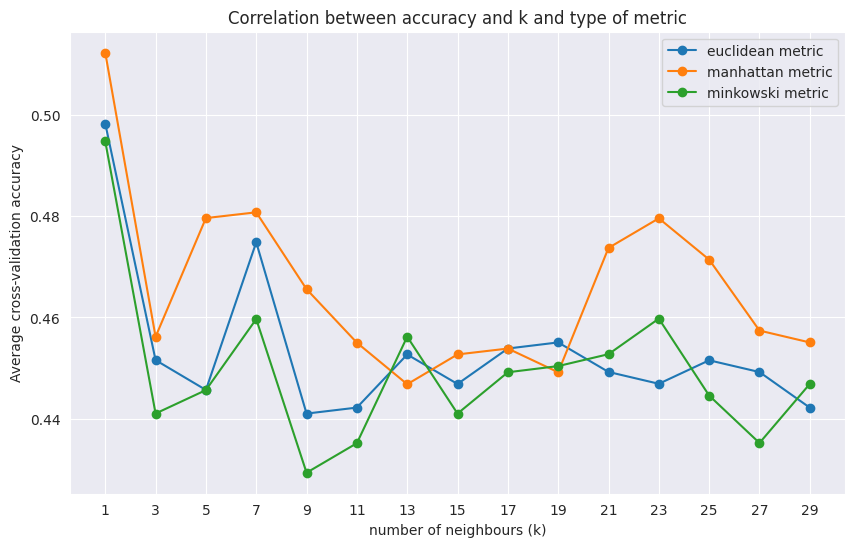

In [37]:
#same graph but without scaling

for metric in metrics:
    cv_scores[metric] = []
    sklearn_p = 2 if metric == 'euclidean' else (3 if metric == 'minkowski' else 1)
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric, p=sklearn_p)
        scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
        cv_scores[metric].append(scores.mean())

plt.figure(figsize=(10, 6))
for metric in metrics:
    plt.plot(k_range, cv_scores[metric], marker='o', label=f'{metric} metric')

plt.title('Correlation between accuracy and k and type of metric')
plt.xlabel('number of neighbours (k)')
plt.ylabel('Average cross-validation accuracy')
plt.xticks(k_range)
plt.grid(True)
plt.legend()
plt.show()

In [45]:
param_grid = {
    'knn__n_neighbors': range(1, 31, 2),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'minkowski'],
}

scaler = StandardScaler().set_output(transform="pandas")

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 90 candidates, totalling 450 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'knn__metric': ['euclidean', 'manhattan', 'minkowski'],
                         'knn__n_neighbors': range(1, 31, 2),
                         'knn__weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=1)

In [46]:
print("\n=== Результаты на синтетических данных ===")
print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучшая CV точность: {grid_search.best_score_:.4f}")
print(f"Тестовая точность: {accuracy_score(y_test, grid_search.predict(X_test)):.4f}")


=== Результаты на синтетических данных ===
Лучшие параметры: {'knn__metric': 'euclidean', 'knn__n_neighbors': 21, 'knn__weights': 'distance'}
Лучшая CV точность: 0.6405
Тестовая точность: 0.6993
